# Деревья решений

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

RANDOM_SEED = 42

Text(0, 0.5, 'X2')

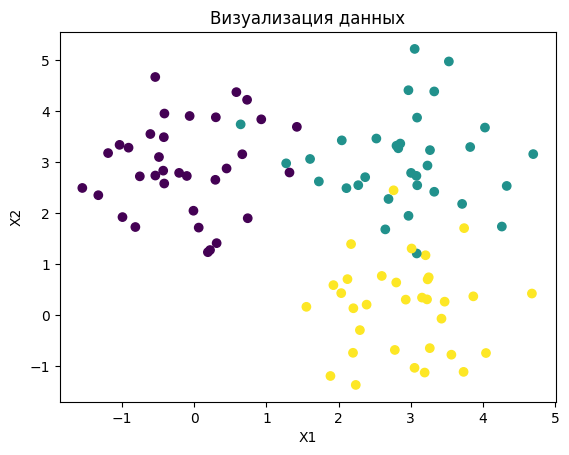

In [68]:
X, y = make_blobs(n_samples=100, centers=[(0,3),(3,3),(3,0)], 
                                      n_features=2, random_state=RANDOM_SEED,
                                      cluster_std=(0.9,0.9,0.9))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Визуализация данных')
plt.xlabel('X1')
plt.ylabel('X2')

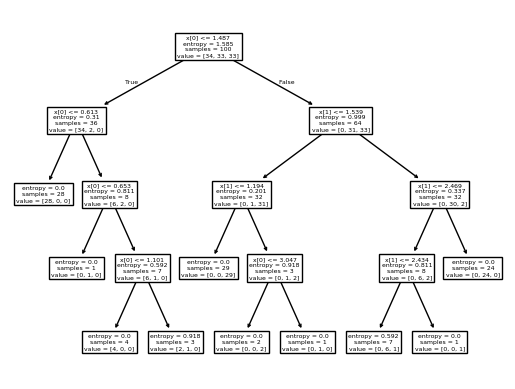

In [69]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

depth=4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth, 
                                  random_state=RANDOM_SEED)
clf_tree.fit(X, y)
tree.plot_tree(clf_tree) 
plt.show()

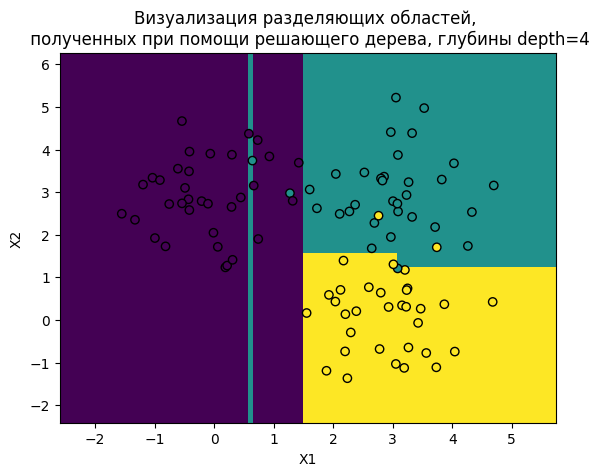

In [70]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [71]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

y_pred = clf_tree.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy =', accuracy_score(y, y_pred))
print('F1_score =', f1_score(y, y_pred, average='micro'))

[[34  0  0]
 [ 1 32  0]
 [ 0  1 32]]
Accuracy = 0.98
F1_score = 0.98


In [72]:
observation_new = [[2, 1]]
clf_tree.predict(observation_new)

array([2])

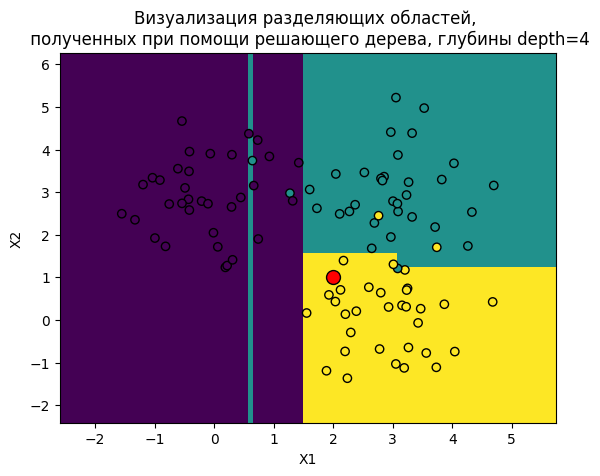

In [73]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(observation_new[0][0], observation_new[0][1], c='red', edgecolors='black', linewidth=1, s=100)
plt.show()

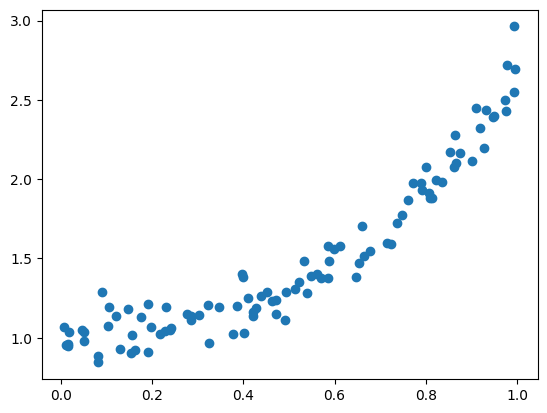

In [74]:
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0])
plt.scatter(X, y)
plt.show()

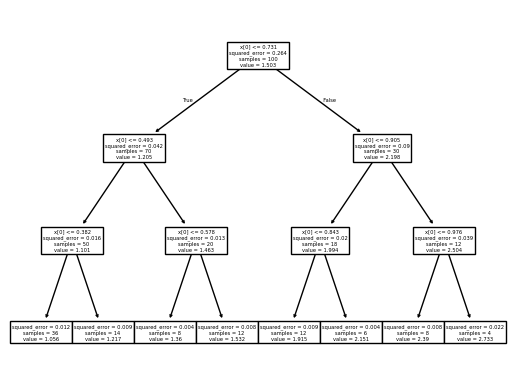

In [75]:
from sklearn.tree import DecisionTreeRegressor

depth=3
X = X.reshape(-1, 1)
reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_SEED)
reg_tree.fit(X, y)
tree.plot_tree(reg_tree)
plt.show()

Text(0, 0.5, 'y')

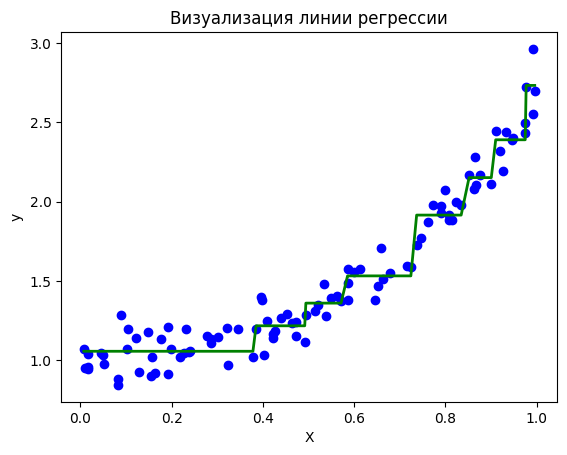

In [76]:
y_pred_reg = reg_tree.predict(X)
plt.scatter(X, y, c="b")
plt.plot(X, y_pred_reg, "g", lw=2)
plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y')

In [77]:
from sklearn.metrics import r2_score, mean_squared_error

print('r2= ', r2_score(y, y_pred_reg))
print('MSE= ', mean_squared_error(y, y_pred_reg))

r2=  0.9637122503261519
MSE=  0.009563878613570777


Text(0, 0.5, 'y')

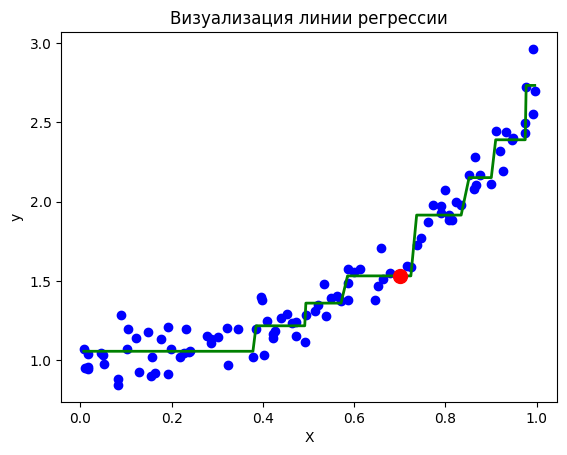

In [78]:
observation_new = [[0.7]]

plt.scatter(X, y, c="b")

plt.plot(X, y_pred_reg, "g", lw=2)
plt.plot(observation_new, reg_tree.predict(observation_new), "ro", markersize=10)

plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y')

## Задания для самостоятельного выполнения

#### 1. Загрузите встроенные данные sklearn.datasets.load_iris, взяв только последние два столбца (длина и ширина лепестков). Изобразите их на диаграмме рассеяния, подкрасив каждый класс некоторым цветом.

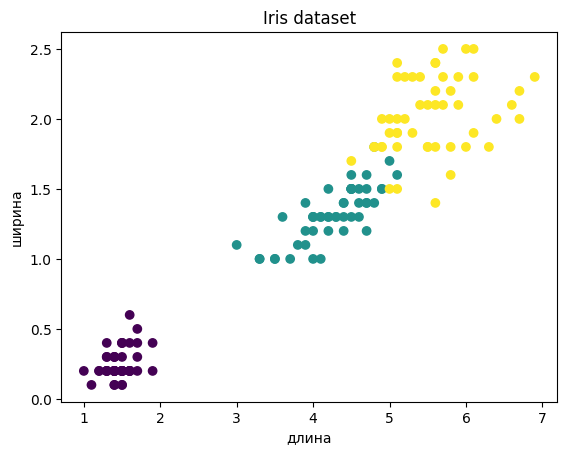

In [79]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data[:, 2:4]
y = iris.target

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Iris dataset")
plt.xlabel("длина")
plt.ylabel("ширина")
plt.show()

#### 2. Обучите модель классификационного дерева принятия решений sklearn.tree.DecisionTreeClassifier глубины 4, используя энтропию. Визуализируйте соответствующий граф дерева принятия решений.

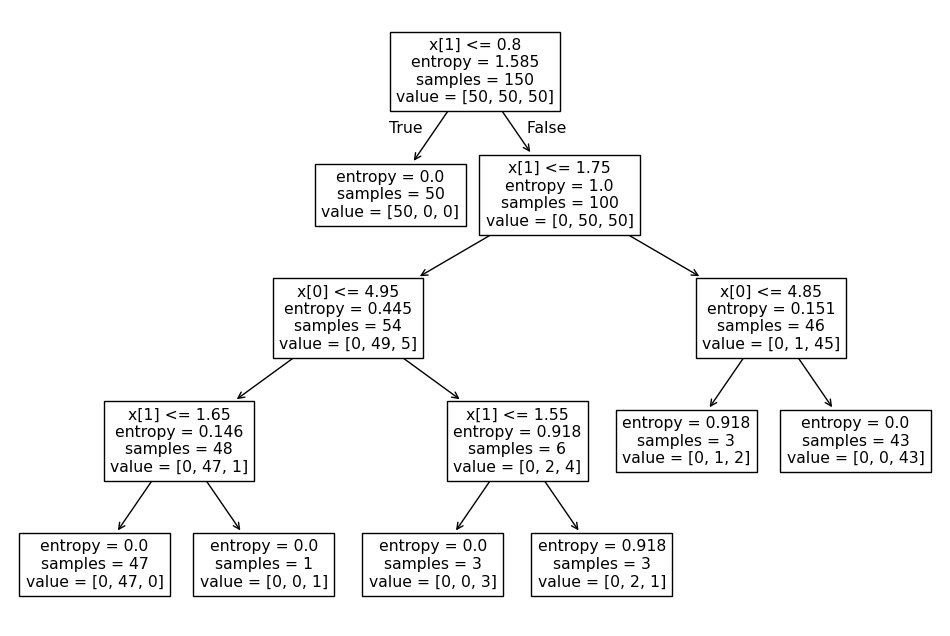

In [80]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

depth = 4
clf_tree = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=0)
clf_tree.fit(X, y)

plt.figure(figsize=(12,8))
tree.plot_tree(clf_tree)
plt.show()

#### 3. Обучите модель классификационного дерева принятия решений sklearn.tree.DecisionTreeClassifier с разными глубинами (1, 2, 3, 4, 10), используя энтропию, и визуализируйте в каждом случае полученные разделяющие области.

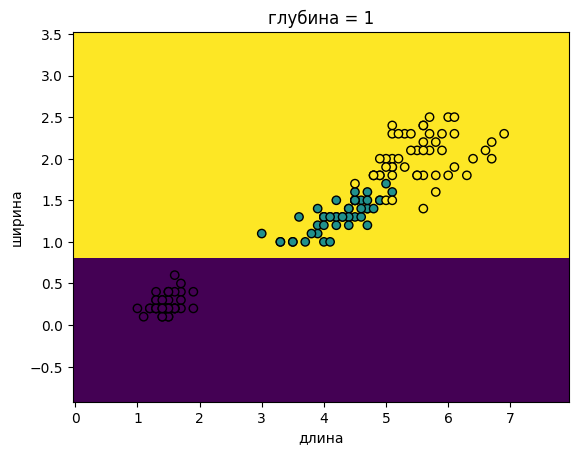

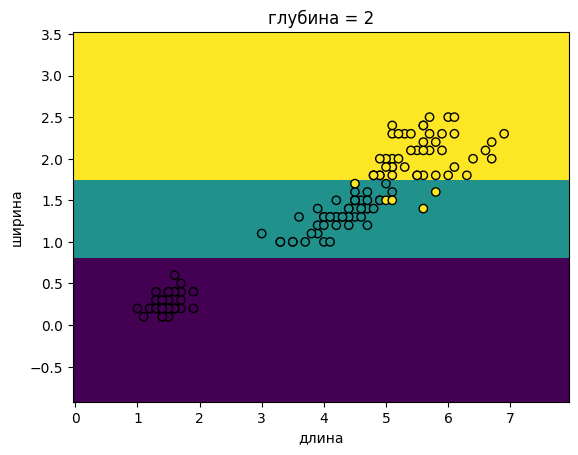

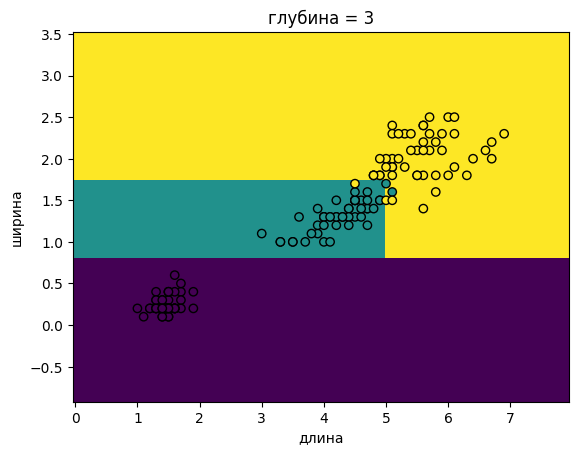

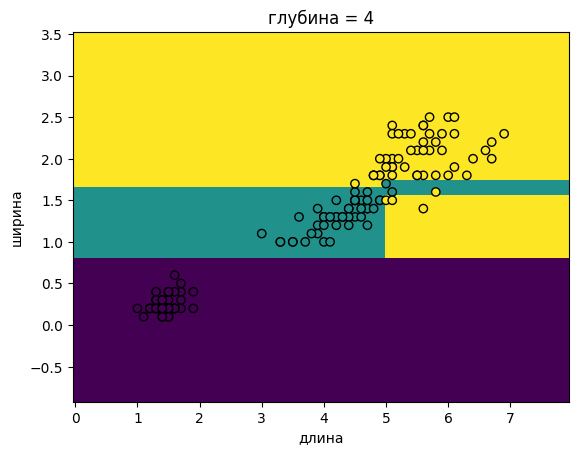

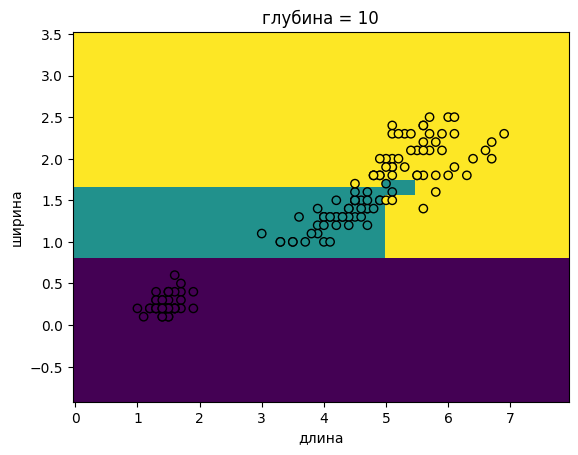

In [81]:
import numpy as np

depths = [1,2,3,4,10]

for depth in depths:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=0)
    clf.fit(X, y)
    X0 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
    X1 = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
    X0_grid, X1_grid = np.meshgrid(X0, X1)
    y_pred = clf.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)

    plt.pcolormesh(X0_grid, X1_grid, y_pred)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors="black")

    plt.title(f"глубина = {depth}")
    plt.xlabel("длина")
    plt.ylabel("ширина")
    plt.show()

#### 4. Выведите необходимые метрики для оценки работы моделей с разными глубинами. Сделайте вывод о том, какая модель лучше классифицирует данные.

In [82]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

depths = [1,2,3,4,10]

for depth in depths:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=0)
    clf.fit(X, y)
    y_pred = clf.predict(X)

    print("Depth:", depth)
    print(confusion_matrix(y, y_pred))
    print("Accuracy:", accuracy_score(y, y_pred))
    print("F1 score:", f1_score(y, y_pred, average="micro"))
    print()
    
# Наилучшие результаты достигаются при глубине дерева 3 и 4. При слишком большой глубине возможно переобучение модели

Depth: 1
[[50  0  0]
 [ 0 50  0]
 [ 0 50  0]]
Accuracy: 0.6666666666666666
F1 score: 0.6666666666666666

Depth: 2
[[50  0  0]
 [ 0 49  1]
 [ 0  5 45]]
Accuracy: 0.96
F1 score: 0.96

Depth: 3
[[50  0  0]
 [ 0 47  3]
 [ 0  1 49]]
Accuracy: 0.9733333333333334
F1 score: 0.9733333333333334

Depth: 4
[[50  0  0]
 [ 0 49  1]
 [ 0  1 49]]
Accuracy: 0.9866666666666667
F1 score: 0.9866666666666667

Depth: 10
[[50  0  0]
 [ 0 49  1]
 [ 0  0 50]]
Accuracy: 0.9933333333333333
F1 score: 0.9933333333333333



#### 5. Загрузите весь датасет load_iris. Обучите модель классификационного дерева принятия решений sklearn.tree.DecisionTreeClassifier глубины 4, используя энтропию. Визуализируйте соответствующий граф дерева решений. Оцените качество работы модели.

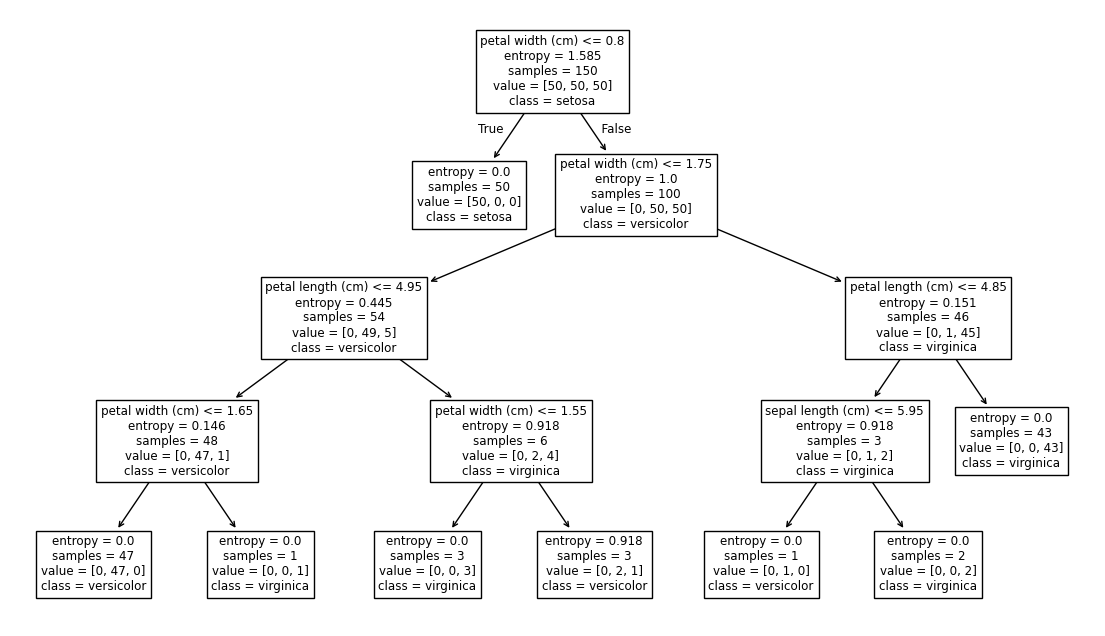

Accuracy: 0.9933333333333333
F1 score: 0.9933333333333333


In [83]:
X_full = iris.data
y_full = iris.target

clf_tree_full = DecisionTreeClassifier(criterion="entropy", max_depth=4,random_state=0)
clf_tree_full.fit(X_full, y_full)

plt.figure(figsize=(14,8))
tree.plot_tree(clf_tree_full, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

y_pred = clf_tree_full.predict(X_full)

print("Accuracy:", accuracy_score(y_full, y_pred))
print("F1 score:", f1_score(y_full, y_pred, average="micro"))

#### 6. Загрузите встроенные данные sklearn.datasets.california_housing, взяв только столбец AveBedrms в качестве единственного признака. Изобразите данные на диаграмме рассеяния так, чтобы на одной оси были отмечены значения признака, а на другой - целевой переменной.

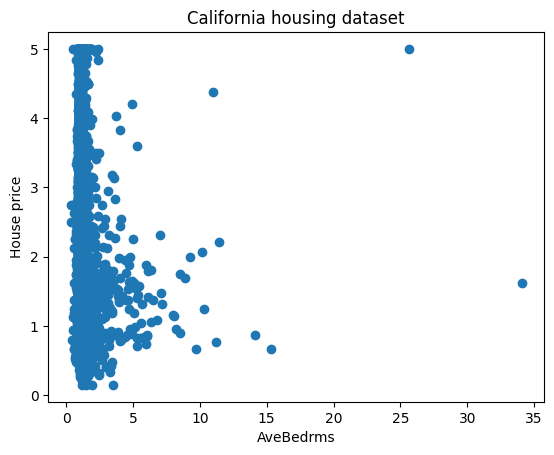

In [84]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
feature_index = list(housing.feature_names).index("AveBedrms")
X = housing.data[:, feature_index].reshape(-1,1)
y = housing.target

plt.scatter(X, y)
plt.xlabel("AveBedrms")
plt.ylabel("House price")
plt.title("California housing dataset")
plt.show()

#### 7. Обучите модель регрессионного дерева принятия решений sklearn.tree.DecisionTreeRegressor, зафиксировав random_state=0, а остальными гиперпараметрами по умолчению.

In [85]:
from sklearn.tree import DecisionTreeRegressor

reg_tree = DecisionTreeRegressor(random_state=0)
reg_tree.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

#### 8. Визуализируйте соответствующий граф дерева решений и получившуюся кусочную линию регрессии.

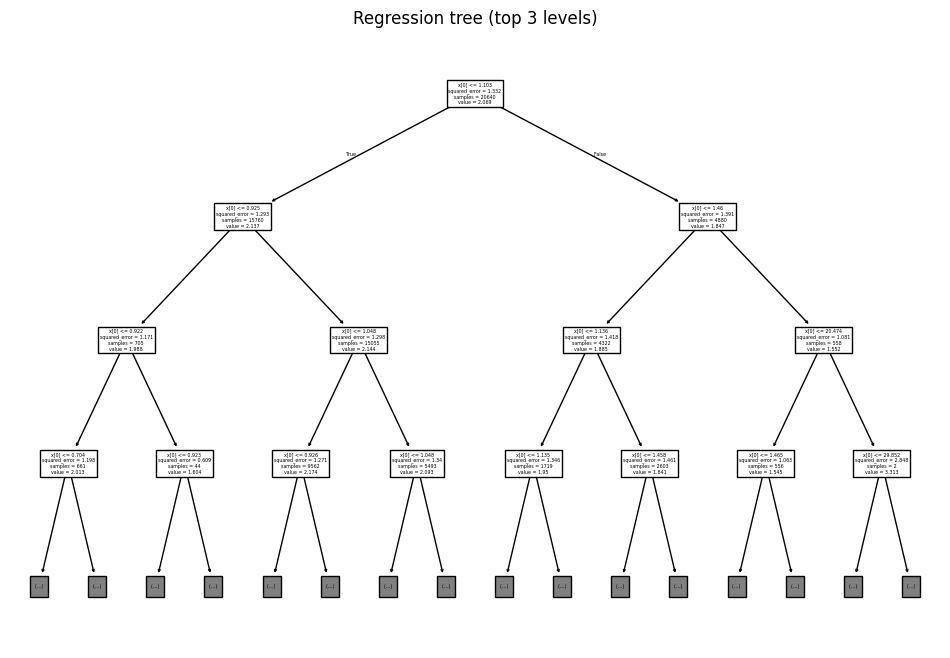

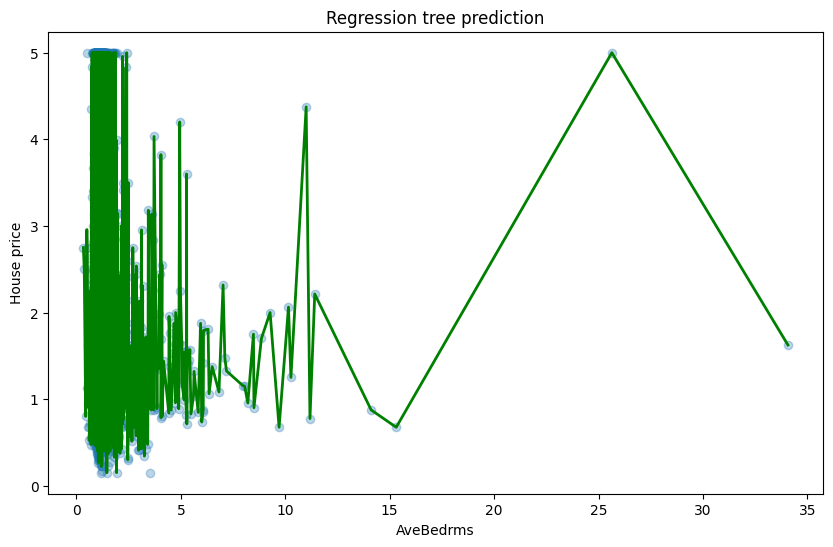

In [86]:
plt.figure(figsize=(12,8))
tree.plot_tree(reg_tree, max_depth=3)
plt.title("Regression tree (top 3 levels)")
plt.show()

y_pred = reg_tree.predict(X)
plt.figure(figsize=(10,6))
plt.scatter(X, y, alpha=0.3)
plt.plot(np.sort(X, axis=0), reg_tree.predict(np.sort(X, axis=0)), color="green", linewidth=2)

plt.xlabel("AveBedrms")
plt.ylabel("House price")
plt.title("Regression tree prediction")
plt.show()

#### 9. Оцените качество работы модели. Создайте новое наблюдение и сделайте предсказание на нём.

In [87]:
from sklearn.metrics import r2_score, mean_squared_error

print("R^2:", r2_score(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))

observation_new = [[3]]
prediction = reg_tree.predict(observation_new)
print("Prediction for AveBedrms=3:", prediction)

R^2: 0.679172913720798
MSE: 0.4271974030094434
Prediction for AveBedrms=3: [0.413]


#### 10. Загрузите весь датасет fetch_california_housing. Обучите ту же модель. Визуализируйте соответствующий граф дерева решений и оцените качество работы модели.

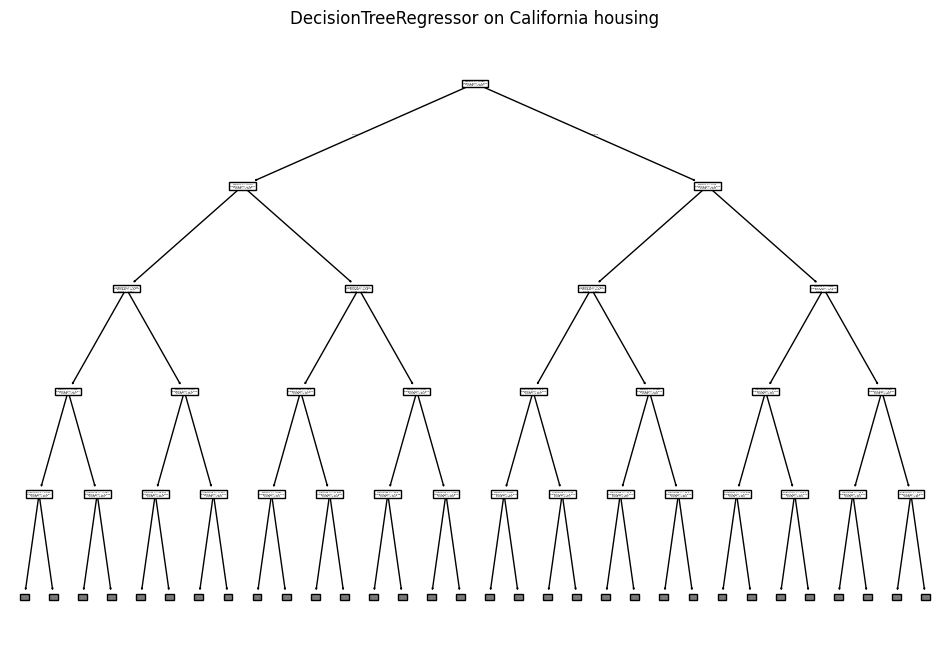

R^2 = 0.6315842747781715
MSE = 0.4905640694739825


In [90]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

housing = fetch_california_housing()
X = housing.data
y = housing.target

reg = DecisionTreeRegressor(random_state=0, max_depth=5)
reg.fit(X, y)

plt.figure(figsize=(12, 8))
tree.plot_tree(reg, feature_names=housing.feature_names, max_depth=4)
plt.title("DecisionTreeRegressor on California housing")
plt.show()

y_pred = reg.predict(X)

print("R^2 =", r2_score(y, y_pred))
print("MSE =", mean_squared_error(y, y_pred))